In [1]:
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore", category=pd.errors.PerformanceWarning)

sc.settings.verbosity = 3
sc.settings.set_figure_params(dpi=80, facecolor='white')
print("Reading data...")
adata = sc.read_h5ad("../Data/Final.h5ad")
adata

Reading data...


AnnData object with n_obs × n_vars = 92942 × 23249
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'group', 'percent.mt', 'percent.hbb', 'percent.hba', 'nCount_SCT', 'nFeature_SCT', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt'
    var: 'total_counts', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts'

In [2]:
# annotate mitochondrial genes as 'mt' and calculate qc metrics
adata.var['mt'] = adata.var_names.str.startswith('mt-')
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)

/home/gupta385/.local/lib/python3.12/site-packages/scanpy/preprocessing/_normalization.py:208: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


normalizing counts per cell
    finished (0:00:00)
extracting highly variable genes
    finished (0:00:00)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)


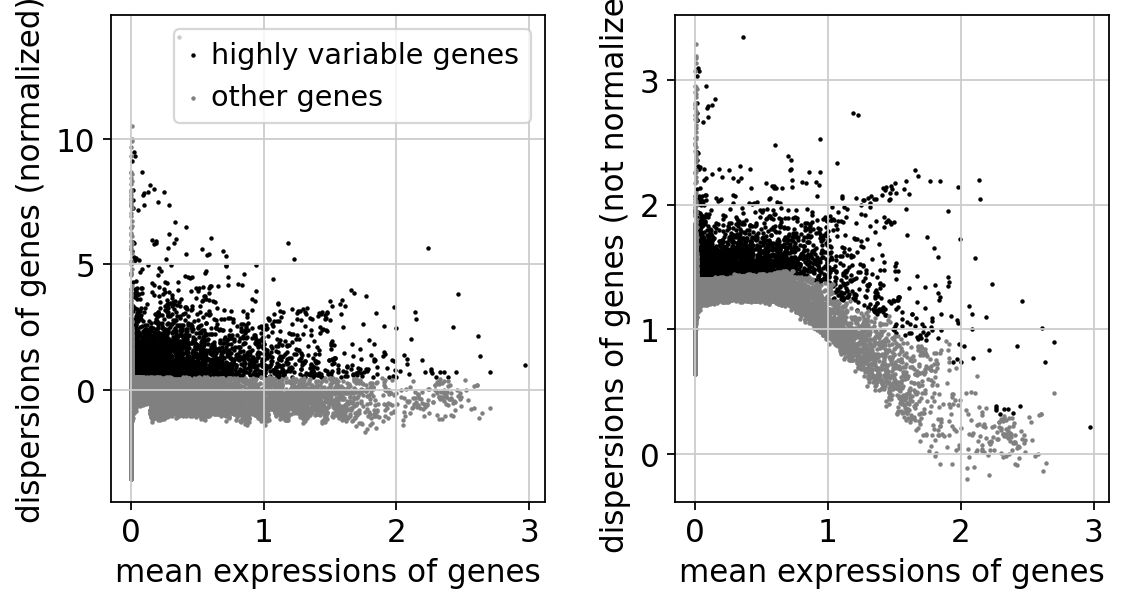

/home/gupta385/.local/lib/python3.12/site-packages/scanpy/preprocessing/_scale.py:317: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


... as `zero_center=True`, sparse input is densified and may lead to large memory consumption
computing PCA
    with n_comps=50
    finished (0:00:18)


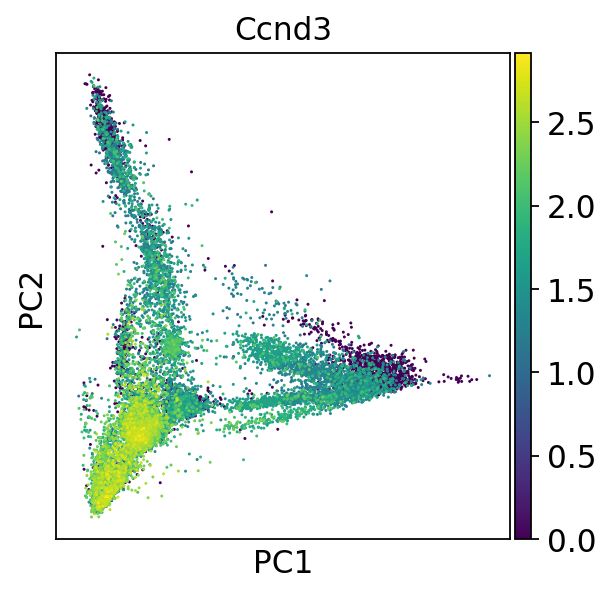

computing neighbors
    using 'X_pca' with n_pcs = 20
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:30)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:17)


In [3]:
#basic filtering
sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=3)

# actually do the filtering by slicing the AnnData object
adata = adata[adata.obs.n_genes_by_counts < 2500, :]
adata = adata[adata.obs.pct_counts_mt < 5, :]

# normalize counts to 10,000 reads per cell..
sc.pp.normalize_total(adata, target_sum=1e4)

#log n+1 transform
sc.pp.log1p(adata)

# identify highly variable genes
sc.pp.highly_variable_genes(adata, min_mean=0.0125, max_mean=3, min_disp=0.5)

#plot dispersion vs expression
sc.pl.highly_variable_genes(adata)

#filter to only include HVGs
adata.raw = adata
adata = adata[:, adata.var.highly_variable]

#scale to unit variance for PCA, clip values exceding var 10
sc.pp.scale(adata, max_value=10)

# reduce the dimensionality of the data with PCA
sc.tl.pca(adata, svd_solver='arpack')

#scatter in the PCA coordinates, won't be used later on, only for vis
sc.pl.pca(adata, color='Ccnd3')

#computing the neighborhood graph
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=20)

#calculating umap coordinates
sc.tl.umap(adata)

running Leiden clustering


/tmp/ipykernel_559340/3543371086.py:3: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata)


    finished: found 41 clusters and added
    'leiden', the cluster labels (adata.obs, categorical) (0:00:00)


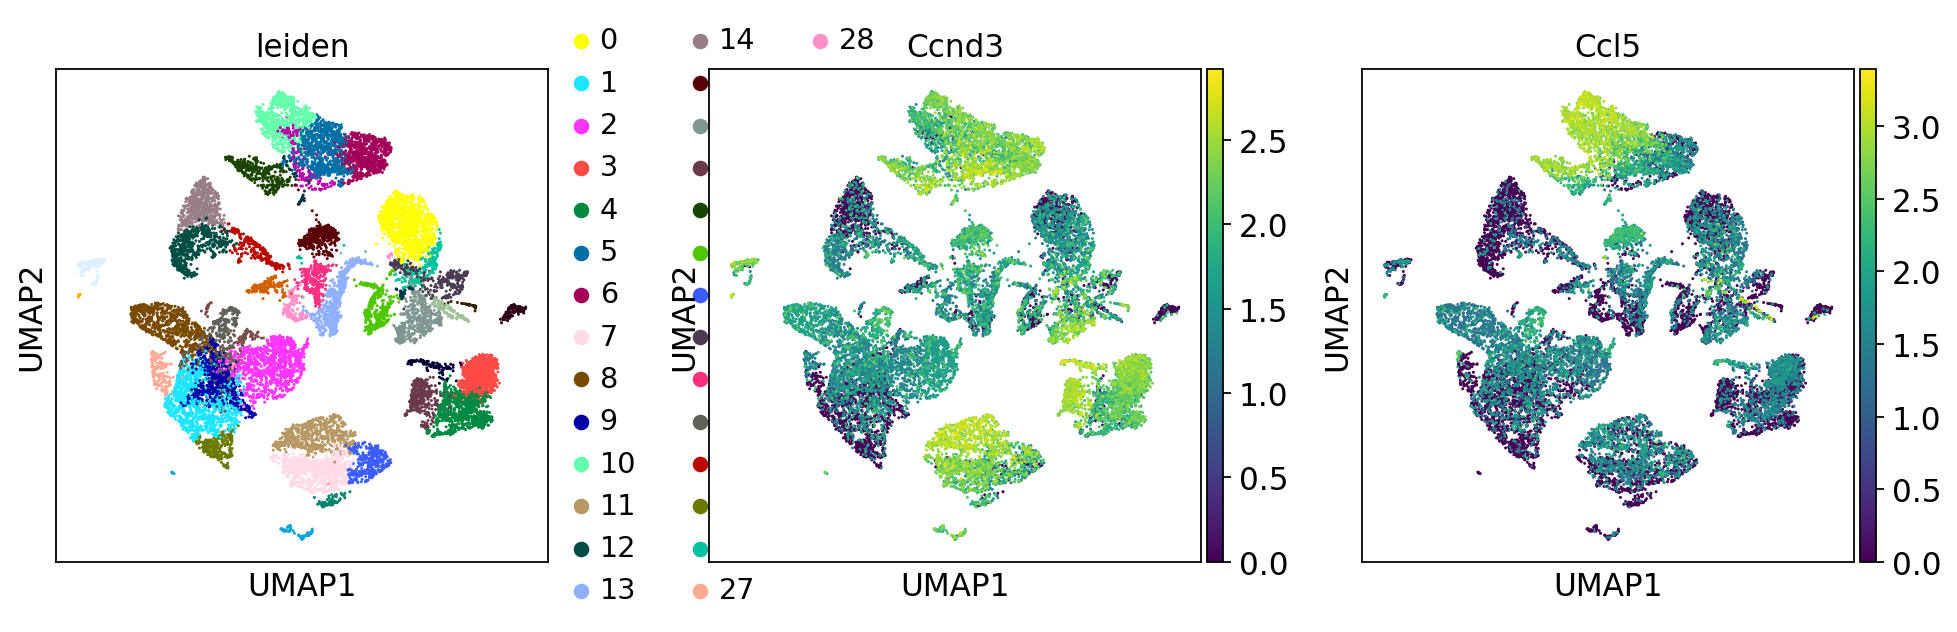

In [4]:
#clustering the neighborhood graph
# run leiden clustering
sc.tl.leiden(adata)

#plot the clusters
sc.pl.umap(adata, color=['leiden', 'Ccnd3', 'Ccl5'])

running PAGA
    finished: added
    'paga/connectivities', connectivities adjacency (adata.uns)
    'paga/connectivities_tree', connectivities subtree (adata.uns) (0:00:00)
--> added 'pos', the PAGA positions (adata.uns['paga'])


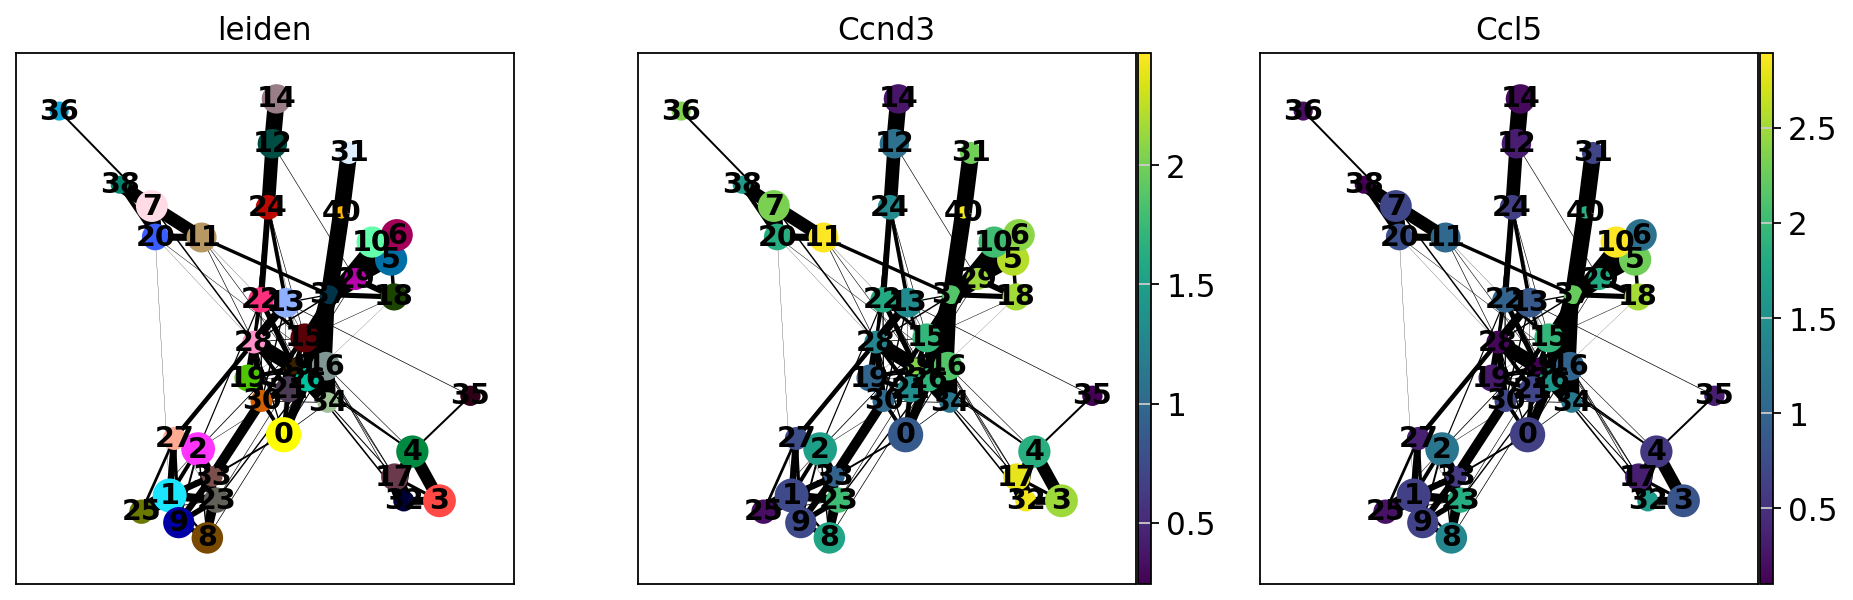

drawing single-cell graph using layout 'fa'
    finished: added
    'X_draw_graph_fa', graph_drawing coordinates (adata.obsm) (0:01:38)


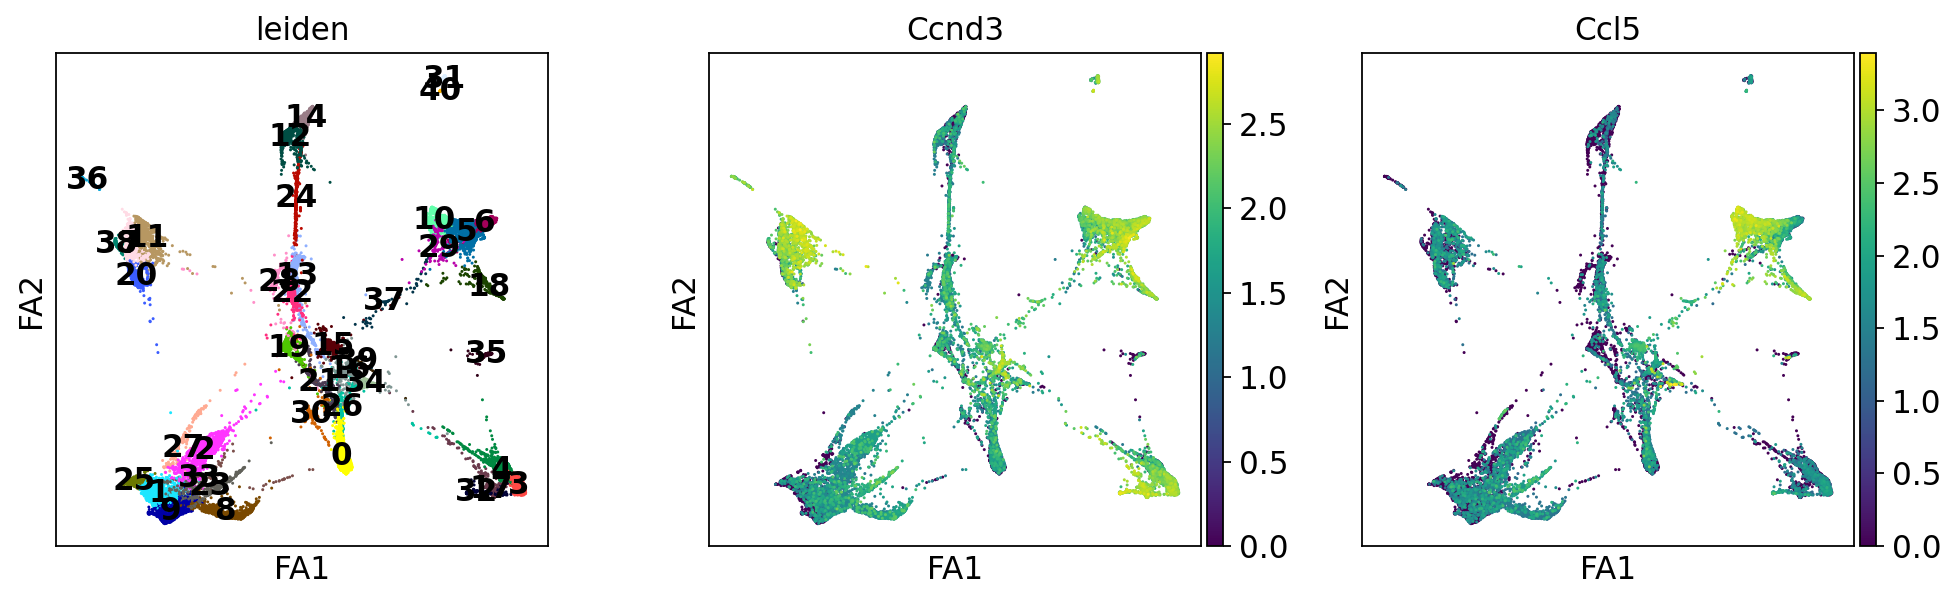

In [5]:
#compute PAGA graph
sc.tl.paga(adata, groups='leiden')
sc.pl.paga(adata, color=['leiden', 'Ccnd3', 'Ccl5'])

#recompute embedding using PAGA initialization
sc.tl.draw_graph(adata, init_pos='paga')
sc.pl.draw_graph(adata, color=['leiden', 'Ccnd3', 'Ccl5'], legend_loc='on data')

ranking genes
    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:16)


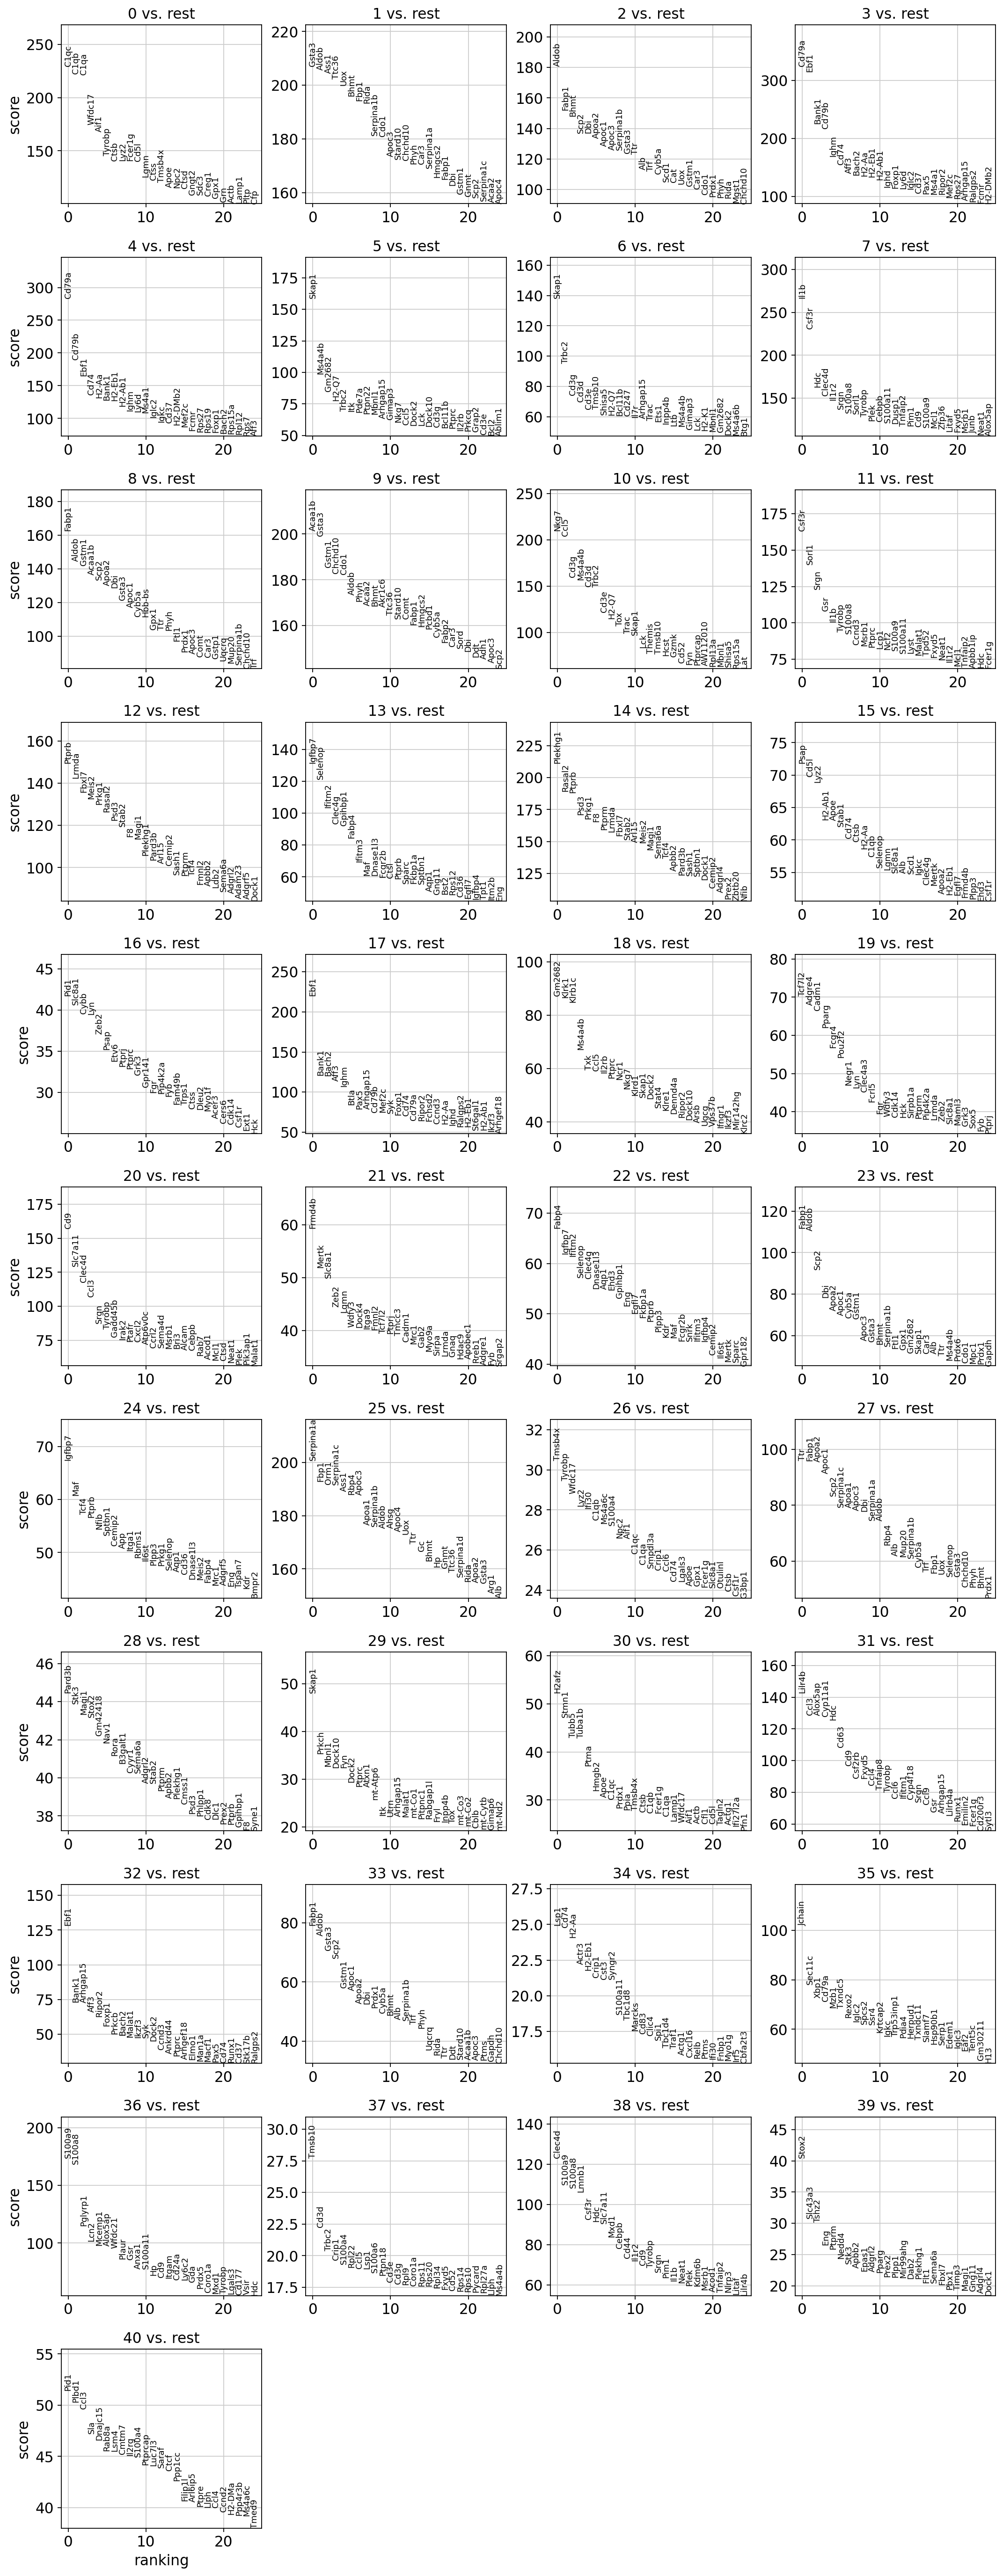

In [6]:
#find marker genes
#compute ranking for differential genes in each cluster
#use raw data
sc.tl.rank_genes_groups(adata, 'leiden', method='t-test')
sc.pl.rank_genes_groups(adata, n_genes=25, sharey=False)

sc.settings.verbosity = 2  # reduce the verbosity

ranking genes
    finished (0:00:46)


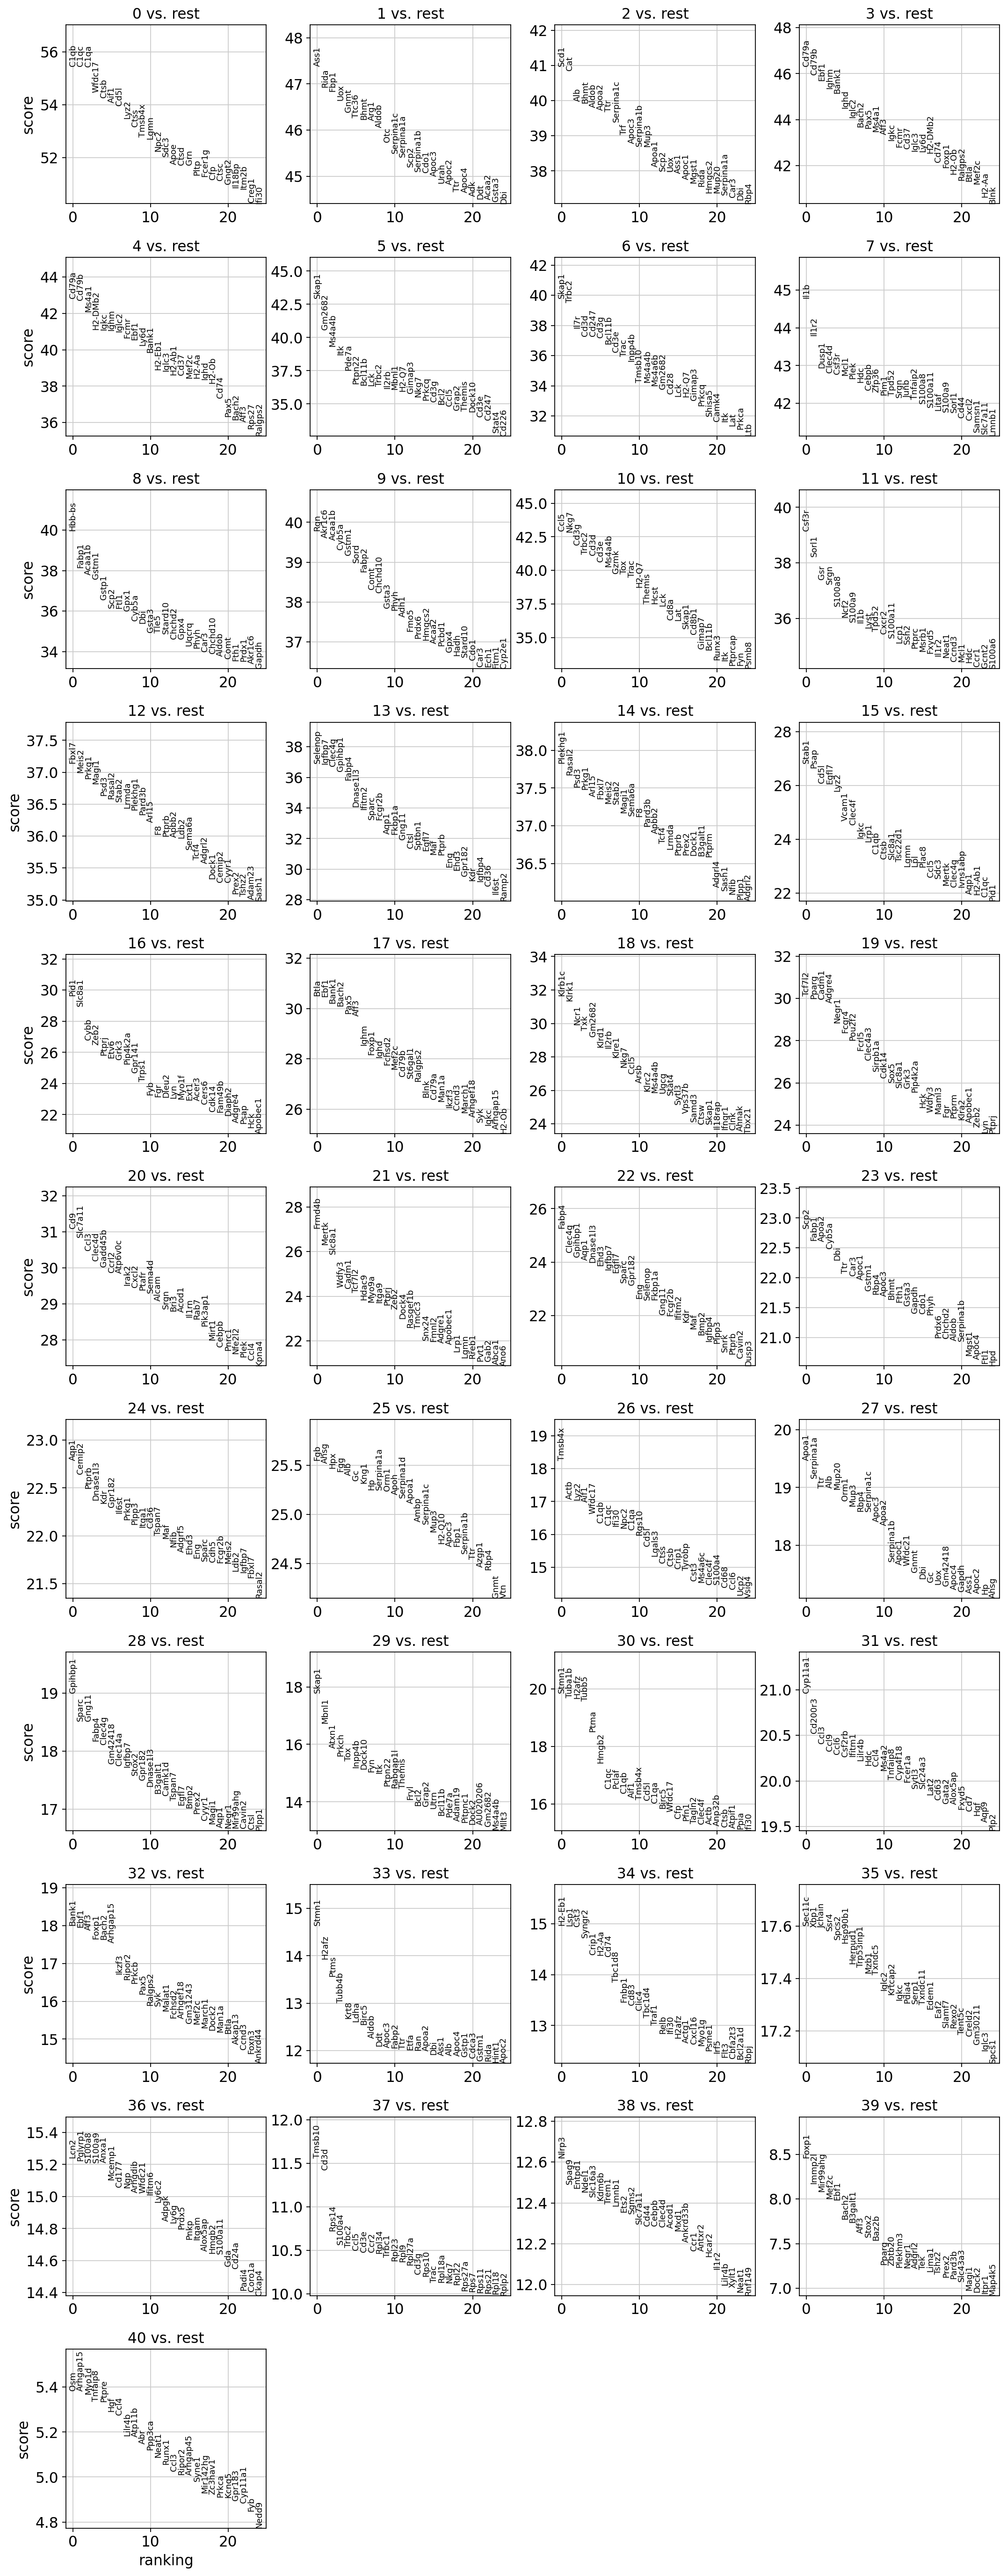

In [7]:
#compute using  wilcoxon rank-sum
sc.tl.rank_genes_groups(adata, 'leiden', method='wilcoxon')
sc.pl.rank_genes_groups(adata, n_genes=25, sharey=False)

In [8]:
results_file = "interm.h5ad"
adata.write(results_file)

ranking genes
    finished (0:00:04)


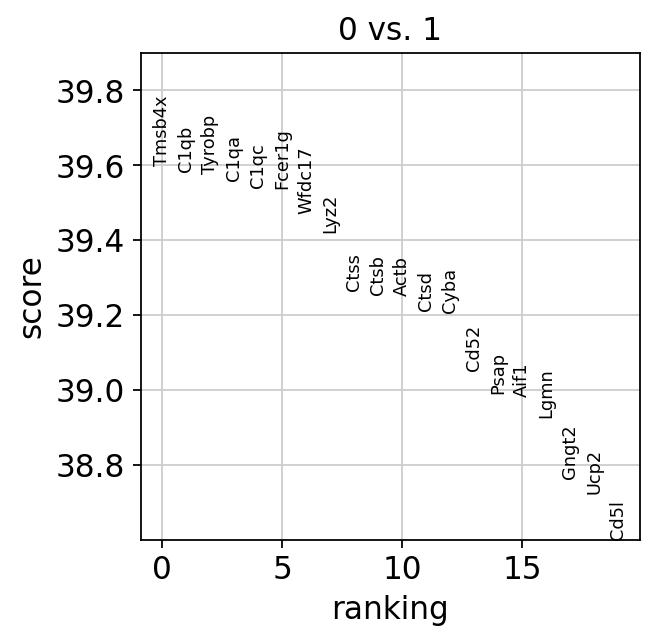

/home/gupta385/.local/lib/python3.12/site-packages/scanpy/plotting/_tools/__init__.py:1331: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  _ax.set_xticklabels(new_gene_names, rotation="vertical")


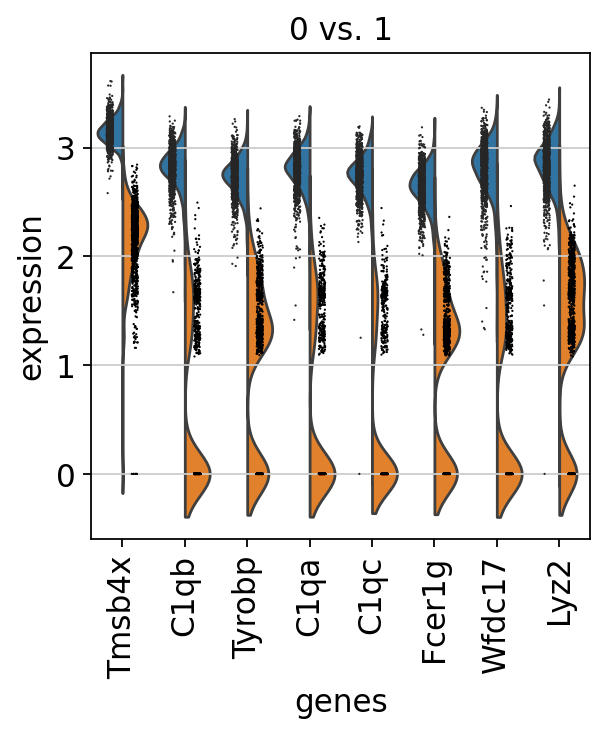

/home/gupta385/.local/lib/python3.12/site-packages/scanpy/plotting/_tools/__init__.py:1331: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  _ax.set_xticklabels(new_gene_names, rotation="vertical")


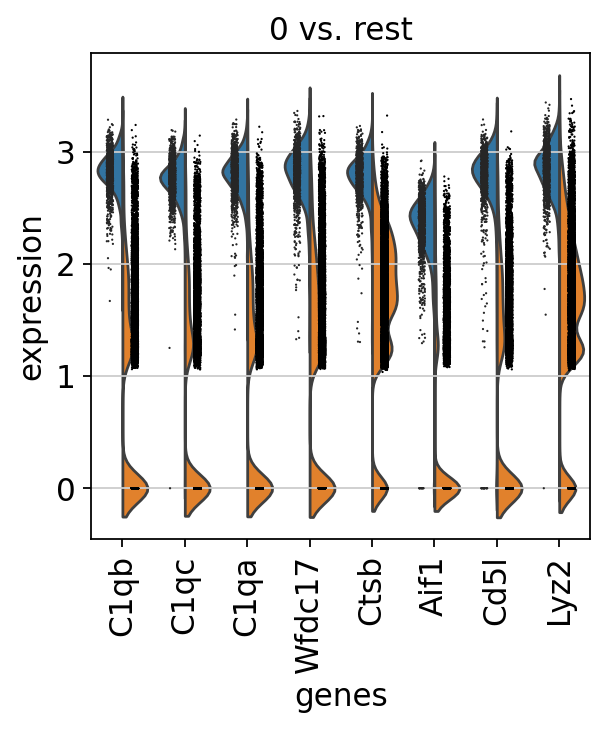

In [9]:
adata = sc.read(results_file)

#show the results
pd.DataFrame(adata.uns['rank_genes_groups']['names']).head(5)

#get a table with scores and groups
result = adata.uns['rank_genes_groups']
groups = result['names'].dtype.names
pd.DataFrame(
    {group + '_' + key[:1]: result[key][group]
    for group in groups for key in ['names', 'pvals']}).head(5)

#compare to a single cluster

sc.tl.rank_genes_groups(adata, 'leiden', groups=['0'], reference='1', method='wilcoxon')
sc.pl.rank_genes_groups(adata, groups=['0'], n_genes=20)

#plot distributions with violin plot
sc.pl.rank_genes_groups_violin(adata, groups='0', n_genes=8)

#compare cluster 0 to rest of groups
adata = sc.read(results_file)
sc.pl.rank_genes_groups_violin(adata, groups='0', n_genes=8)

In [12]:
adata = sc.read(results_file)  # Load your AnnData object

results = adata.uns['rank_genes_groups']
names = results['names']

# Get the names for a specific cluster (e.g., cluster '0')
marker_genes_cluster_0 = names['0']  # Access names for cluster '0'

# Print the top marker genes for cluster '0'
print("Top marker genes for cluster 0:")
print(marker_genes_cluster_0[:20])

Top marker genes for cluster 0:
['C1qb' 'C1qc' 'C1qa' 'Wfdc17' 'Ctsb' 'Aif1' 'Cd5l' 'Lyz2' 'Ctss' 'Tmsb4x'
 'Lgmn' 'Npc2' 'Sdc3' 'Apoe' 'Ctsd' 'Grn' 'Pltp' 'Fcer1g' 'Cfp' 'Ctsc']


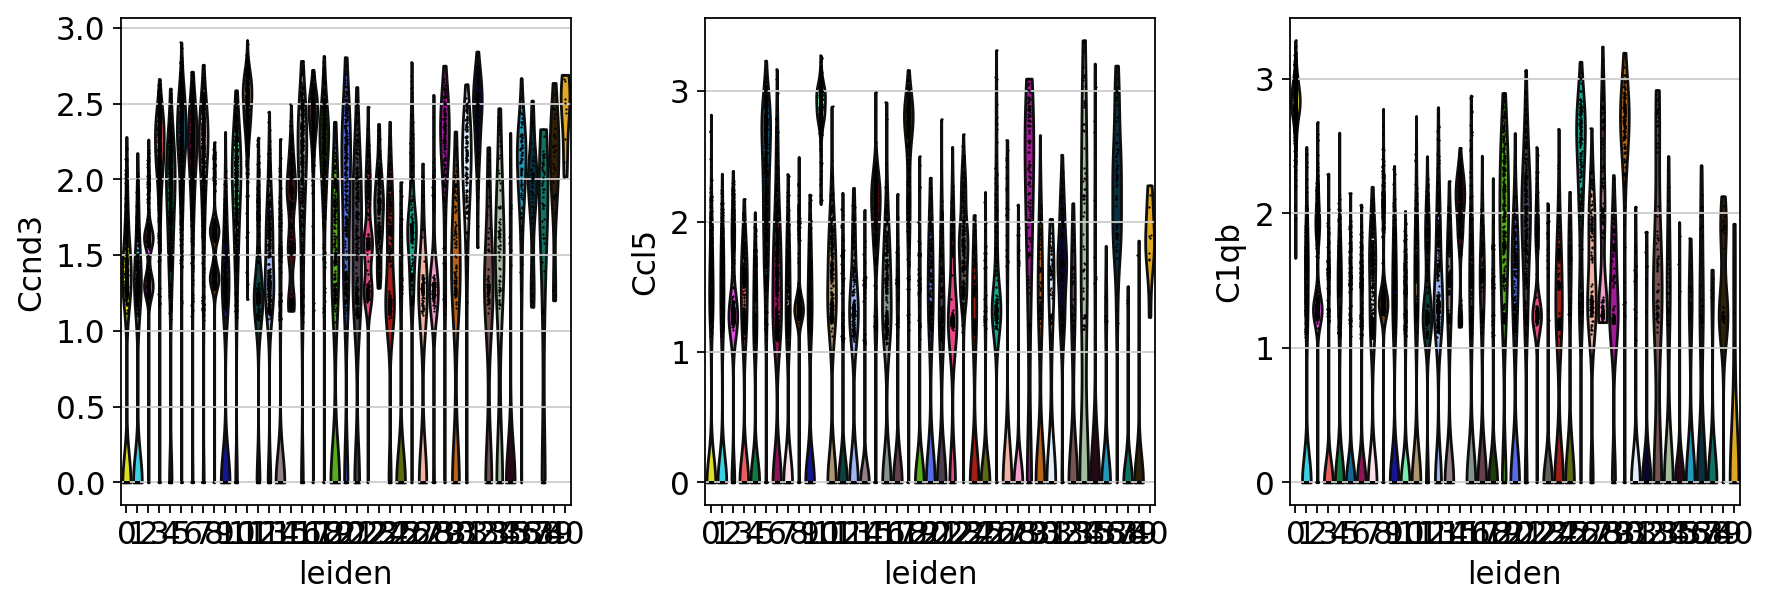

ValueError: new categories need to have the same number of items as the old categories!

In [14]:
#define list for reference
marker_genes = marker_genes_cluster_0[:20]

#compare a certain gene across groups
sc.pl.violin(adata, ['Ccnd3', 'Ccl5', 'C1qb'], groupby='leiden')

#label the cell types
new_cluster_names = [
    'extra cluster','CD4 T', 'CD14 Monocytes',
    'B', 'CD8 T',
    'NK', 'FCGR3A Monocytes',
    'Dendritic', 'Megakaryocytes']
adata.rename_categories('leiden', new_cluster_names)
sc.pl.umap(adata, color='leiden', legend_loc='on data', title='', frameon=False, save='.pdf')

#visualize the marker genes in a dotplot
sc.pl.dotplot(adata, marker_genes, groupby='leiden');

#visualize marker gene distributions in a dot plot
sc.pl.stacked_violin(adata, marker_genes, groupby='leiden', rotation=90);

#save results
adata.write(results_file, compression='gzip')  # `compression='gzip'` saves disk space, but slows down writing and subsequent reading